In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

with open("word2int_en.pkl", "rb") as f:
    en_words = pickle.load(f)
with open("word2int_fr.pkl", "rb") as f:
    fr_words = pickle.load(f)

en_embeddings = np.load('embeddings_en.npz')["embeddings"]
fr_embeddings = np.load('embeddings_fr.npz')['embeddinngs']

def tokenize(sentence, token_mappings):
    tokenized =[]
    for word in sentence.lower().split(" "):
        try:
            tokenized.append(token_mapping[word])
        except KeyError:
            tokenized.append(-1)
    return tokenized

def embed(tokens, embeddings):
    embed_size = embeddings.shape[1]
    output = np.zeros((len(tokens), embed_size))
    for i,token in enumerate(tokens):
        if token == -1:
            output[i] = np.zeros((1, embed_size))
        else:
            output[i] = embeddings[token]

    return output

FileNotFoundError: [Errno 2] No such file or directory: 'word2int_en.pkl'

In [ ]:
sentence_en = "The agreement on the European Economic Area was signed in August 1992 ."
tokenized_en = tokenize(sentence_en, en_words)
embedded_en = embed(tokenized_en, en_embeddings)

sentence_fr = "L accord sur la zone economique europeenne a ete signe en aout 1992 ."
tokenized_fr = tokenize(sentence_fr, fr_words)
embedded_fr = embed(tokenized_fr, fr_embeddings)

alignment = calculate_weights(embedded_fr, embedded_en)
fig, ax = plt.subplots(figsize=(7,7))
ax.imshow(alignment, cmap="gray")
ax.xaxis.tick_top()
ax.set_xticks(np.arange(alignmen.shape[1]))
ax.set_xticklabels(sentence_en.split(" "), rotation = 90, size = 16);
ax.set_yticks(np.arange(alignment.shape[0]));
ax.set_yticklabels(sentence_fr.split(" "), size = 16);

In [3]:
import numpy as np
import nltk
nltk.download("punkt")
from nltk.util import ngrams
from collections import Counter
!pip install sacrebleu
import sacrebleu
import matplotlib.pyplot as plt


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


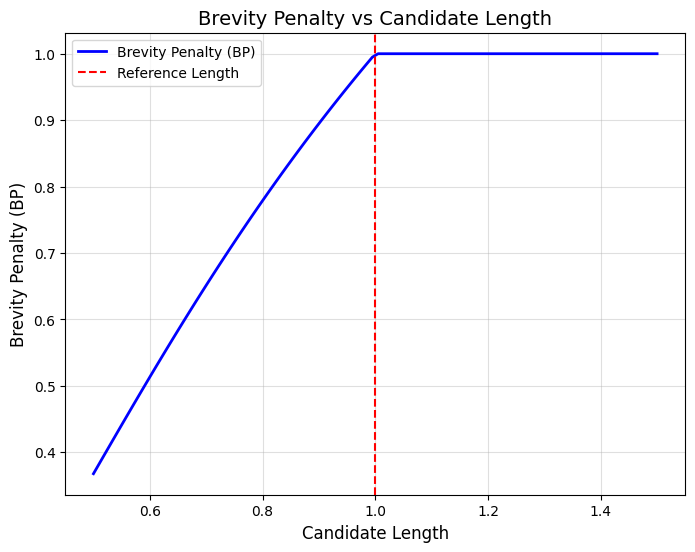

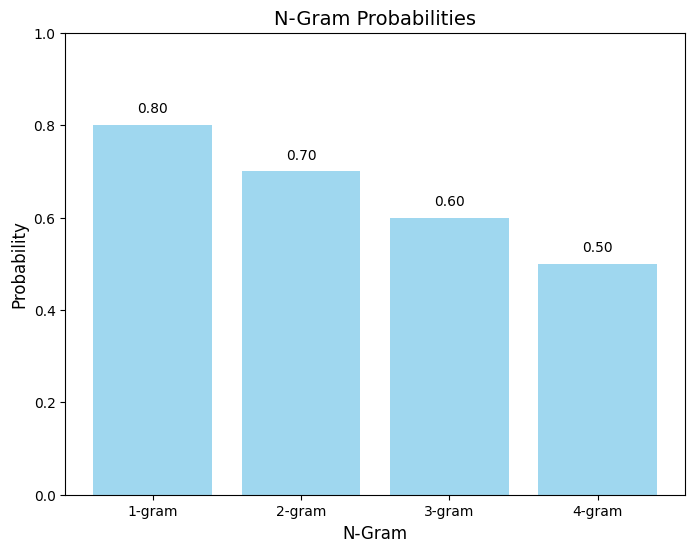

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Part 1: Brevity Penalty Plot
# Define lengths and compute length ratio
reference_length = 1
candidate_length = np.linspace(1.5, 0.5, 100)  # Range of candidate lengths
length_ratio = reference_length / candidate_length

# Compute brevity penalty (BP)
bp = np.minimum(1, np.exp(1 - length_ratio))

# Plot brevity penalty results
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(candidate_length, bp, label='Brevity Penalty (BP)', color='blue', linewidth=2)
ax.set_title("Brevity Penalty vs Candidate Length", fontsize=14)
ax.set_xlabel("Candidate Length", fontsize=12)
ax.set_ylabel("Brevity Penalty (BP)", fontsize=12)
ax.axvline(reference_length, color='red', linestyle='--', label='Reference Length')
ax.legend(fontsize=10)
ax.grid(alpha=0.4)

plt.show()

# Part 2: N-Gram Bar Chart
# Define n-gram data
data = {
    "1-gram": 0.8,
    "2-gram": 0.7,
    "3-gram": 0.6,
    "4-gram": 0.5
}

# Extract keys and values from the data
keys, values = zip(*data.items())

# Create the bar chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(keys, values, color='skyblue', alpha=0.8)

# Add labels and title for the bar chart
ax.set_title("N-Gram Probabilities", fontsize=14)
ax.set_xlabel("N-Gram", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.set_ylim(0, 1)  # Ensure y-axis is scaled between 0 and 1

# Add value annotations on top of the bars
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{value:.2f}", ha='center', va='bottom', fontsize=10)

plt.show()
